# Catalog BAO/AP validation walkthrough

This notebook is the rendered walkthrough for the `desiblind.CatalogBAOBlinder`
validation. It lives beside the validation scripts so validation material is kept in
one structure: `scripts/validation/`.

It does **not** rerun the expensive LSS jobs. Instead, it loads the summary JSON files
produced by the validation scripts, asserts the pass criteria, and plots representative
final-statistics residuals.

Main question:

> Can `desiblind.CatalogBAOBlinder` replace the LSS BAO/AP catalog redshift shifter,
> and can `desi-clustering` use it natively for blinded Pk/xi measurements with an
> option to save the blinded catalogs?


## Validation ladder

The validation is staged from the smallest operation to native measurement integration:

1. BAO/AP redshift remapping only.
2. LSS `n(z)` / `WEIGHT_SYS` compatibility.
3. Saved full-catalog workflow including `WEIGHT_FKP`.
4. LSS `mkclusdat` clustering-data generation.
5. LSS `mkclusran` clustering-random generation.
6. Galactic-cap split of clustering catalogs.
7. Production-like full random 0 and multi-random 1--17 saved-catalog coverage.
8. Final Pk/xi through `desi-clustering`: LSS-produced blinded catalogs vs desiblind-produced blinded catalogs.
9. Native `desi-clustering` integration smoke: run blinded Pk/xi, save catalogs, rerun from saved catalogs.


In [1]:
from pathlib import Path
import json
import math

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_colwidth', 160)

DESIBLIND_REPO = Path('/global/homes/u/uendert/repos/desi/desiblind')
DESI_CLUSTERING_REPO = Path('/global/homes/u/uendert/repos/desi/desi-clustering')
LSS_VALIDATION_ROOT = Path('/pscratch/sd/u/uendert/desiblind_lss_validation')

SUMMARY_PATHS = {
    'redshift': LSS_VALIDATION_ROOT / 'redshift-shift-20260623-161524-474608/summary.json',
    'nz_weight': LSS_VALIDATION_ROOT / 'nz-weight-20260623-162814-1783843/summary.json',
    'saved_catalog': LSS_VALIDATION_ROOT / 'saved-catalog-20260623-162741-709548/summary.json',
    'mkclusdat': LSS_VALIDATION_ROOT / 'mkclusdat-20260623-174134-2237333/summary.json',
    'mkclusran': LSS_VALIDATION_ROOT / 'mkclusran-20260623-175319-1738761/summary.json',
    'split_gc_small': LSS_VALIDATION_ROOT / 'split-gc-20260623-185302-1647449/summary.json',
    'production_random0': LSS_VALIDATION_ROOT / 'production-54906853-0/summary.json',
    'multi_randoms_1_17': LSS_VALIDATION_ROOT / 'multi-randoms-20260623-213146-1005132/summary.json',
    'desi_clustering_pk': LSS_VALIDATION_ROOT / 'desi-clustering-pk-bao-validated-20260625T130130Z/summary.json',
    'desi_clustering_xi': LSS_VALIDATION_ROOT / 'desi-clustering-xi-wide-20260625T114027Z/summary.json',
    'native_pk_smoke': Path('/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/native_smoke_summary.json'),
    'native_xi_smoke': Path('/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/native_xi_smoke_summary.json'),
}

for name, path in SUMMARY_PATHS.items():
    assert path.exists(), f'Missing summary for {name}: {path}'

summaries = {name: json.loads(path.read_text()) for name, path in SUMMARY_PATHS.items()}
print('Loaded summaries:')
for name, path in SUMMARY_PATHS.items():
    print(f'  {name:24s} {path}')


Loaded summaries:
  redshift                 /pscratch/sd/u/uendert/desiblind_lss_validation/redshift-shift-20260623-161524-474608/summary.json
  nz_weight                /pscratch/sd/u/uendert/desiblind_lss_validation/nz-weight-20260623-162814-1783843/summary.json
  saved_catalog            /pscratch/sd/u/uendert/desiblind_lss_validation/saved-catalog-20260623-162741-709548/summary.json
  mkclusdat                /pscratch/sd/u/uendert/desiblind_lss_validation/mkclusdat-20260623-174134-2237333/summary.json
  mkclusran                /pscratch/sd/u/uendert/desiblind_lss_validation/mkclusran-20260623-175319-1738761/summary.json
  split_gc_small           /pscratch/sd/u/uendert/desiblind_lss_validation/split-gc-20260623-185302-1647449/summary.json
  production_random0       /pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/summary.json
  multi_randoms_1_17       /pscratch/sd/u/uendert/desiblind_lss_validation/multi-randoms-20260623-213146-1005132/summary.json
  desi_c

## Helpers

The validation scripts store nested dictionaries. We recursively collect every numeric
`max_abs_delta*` field so each stage can be checked with a compact pass/fail rule.


In [2]:
def iter_delta_items(obj, prefix=''):
    if isinstance(obj, dict):
        for key, value in obj.items():
            path = f'{prefix}.{key}' if prefix else str(key)
            if 'max_abs_delta' in str(key) and isinstance(value, (int, float)) and math.isfinite(value):
                yield path, float(value)
            yield from iter_delta_items(value, path)
    elif isinstance(obj, list):
        for i, value in enumerate(obj):
            yield from iter_delta_items(value, f'{prefix}[{i}]')

def max_abs_delta(obj):
    values = list(iter_delta_items(obj))
    return max([delta for _, delta in values] or [0.0])

def rows_from_summary(obj):
    rows = []
    def rec(x):
        if isinstance(x, dict):
            if isinstance(x.get('rows'), int):
                rows.append(x['rows'])
            for v in x.values():
                rec(v)
        elif isinstance(x, list):
            for v in x:
                rec(v)
    rec(obj)
    return max(rows) if rows else None

def status_mark(ok):
    return 'PASS' if ok else 'FAIL'


## 1--7. LSS saved-catalog validation

These rows compare the LSS reference branch with the desiblind branch, where the only
intended change is replacing the LSS BAO/AP redshift shifter with
`CatalogBAOBlinder` before the same downstream LSS functions are called.


In [3]:
ladder_specs = [
    ('1', 'redshift remapping', 'validate_catalog_bao_lss_redshift_shift.py', 'redshift', 0.0,
     'LSS apply_zshift_DE vs CatalogBAOBlinder'),
    ('2', 'n(z) / WEIGHT_SYS', 'validate_catalog_bao_lss_nz_weight.py', 'nz_weight', 0.0,
     'Z, n(z), and WEIGHT_SYS'),
    ('3', 'saved full catalog / WEIGHT_FKP', 'validate_catalog_bao_lss_saved_catalog_bao.py', 'saved_catalog', 0.0,
     'saved full catalog, WEIGHT_SYS, WEIGHT_FKP, n(z)'),
    ('4', 'mkclusdat', 'validate_catalog_bao_lss_mkclusdat.py', 'mkclusdat', 0.0,
     'LSS clustering-data catalog'),
    ('5', 'mkclusran', 'validate_catalog_bao_lss_mkclusran.py', 'mkclusran', 0.0,
     'LSS clustering-random catalog'),
    ('6', 'GC split sample', 'validate_catalog_bao_lss_split_gc.py', 'split_gc_small', 0.0,
     'NGC/SGC split on scratch sample'),
    ('7a', 'production random 0', 'validate_catalog_bao_lss_split_gc.py', 'production_random0', 0.0,
     'Full data + full random 0'),
    ('7b', 'multi-randoms 1--17', 'validate_catalog_bao_lss_multi_randoms.py', 'multi_randoms_1_17', 0.0,
     'Full data reused once; randoms 1--17'),
]
rows = []
for step, label, script, key, tol, note in ladder_specs:
    summary = summaries[key]
    delta = max_abs_delta(summary)
    rows.append({
        'step': step, 'validation': label, 'script': script,
        'summary': str(SUMMARY_PATHS[key]), 'max_abs_delta': delta,
        'tolerance': tol, 'status': status_mark(delta <= tol),
        'rows_max_seen': rows_from_summary(summary), 'note': note,
    })
ladder_df = pd.DataFrame(rows)
display(ladder_df)
assert (ladder_df['status'] == 'PASS').all(), ladder_df


,step,validation,script,summary,max_abs_delta,tolerance,status,rows_max_seen,note
0,1,redshift remapping,validate_catalog_bao_lss_redshift_shift.py,/pscratch/sd/u/uendert/desiblind_lss_validation/redshift-shift-20260623-161524-474608/summary.json,0.0,0.0,PASS,4,LSS apply_zshift_DE vs CatalogBAOBlinder
1,2,n(z) / WEIGHT_SYS,validate_catalog_bao_lss_nz_weight.py,/pscratch/sd/u/uendert/desiblind_lss_validation/nz-weight-20260623-162814-1783843/summary.json,0.0,0.0,PASS,20000,"Z, n(z), and WEIGHT_SYS"
2,3,saved full catalog / WEIGHT_FKP,validate_catalog_bao_lss_saved_catalog_bao.py,/pscratch/sd/u/uendert/desiblind_lss_validation/saved-catalog-20260623-162741-709548/summary.json,0.0,0.0,PASS,20000,"saved full catalog, WEIGHT_SYS, WEIGHT_FKP, n(z)"
3,4,mkclusdat,validate_catalog_bao_lss_mkclusdat.py,/pscratch/sd/u/uendert/desiblind_lss_validation/mkclusdat-20260623-174134-2237333/summary.json,0.0,0.0,PASS,20000,LSS clustering-data catalog
4,5,mkclusran,validate_catalog_bao_lss_mkclusran.py,/pscratch/sd/u/uendert/desiblind_lss_validation/mkclusran-20260623-175319-1738761/summary.json,0.0,0.0,PASS,50000,LSS clustering-random catalog
5,6,GC split sample,validate_catalog_bao_lss_split_gc.py,/pscratch/sd/u/uendert/desiblind_lss_validation/split-gc-20260623-185302-1647449/summary.json,0.0,0.0,PASS,24000,NGC/SGC split on scratch sample
6,7a,production random 0,validate_catalog_bao_lss_split_gc.py,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/summary.json,0.0,0.0,PASS,25061644,Full data + full random 0
7,7b,multi-randoms 1--17,validate_catalog_bao_lss_multi_randoms.py,/pscratch/sd/u/uendert/desiblind_lss_validation/multi-randoms-20260623-213146-1005132/summary.json,0.0,0.0,PASS,25067462,Full data reused once; randoms 1--17


### Multi-random details

Random 0 was run in the production-like split-GC validation. This table shows the
multi-random run for randoms 1--17. All random-catalog and split-GC deltas are zero.


In [4]:
multi = summaries['multi_randoms_1_17']
random_rows = []
for rannum, result in sorted(multi['randoms'].items(), key=lambda item: int(item[0])):
    delta = max_abs_delta(result)
    random_rows.append({
        'rannum': int(rannum),
        'random_rows': result.get('random_rows'),
        'max_abs_delta': delta,
        'status': status_mark(delta == 0.0),
    })
random_df = pd.DataFrame(random_rows)
display(random_df)
assert len(random_df) == 17
assert set(random_df['rannum']) == set(range(1, 18))
assert (random_df['max_abs_delta'] == 0.0).all()


,rannum,random_rows,max_abs_delta,status
0,1,25059857,0.0,PASS
1,2,25053548,0.0,PASS
2,3,25059435,0.0,PASS
3,4,25061341,0.0,PASS
4,5,25064453,0.0,PASS
5,6,25061921,0.0,PASS
6,7,25062243,0.0,PASS
7,8,25062555,0.0,PASS
8,9,25056433,0.0,PASS
9,10,25059092,0.0,PASS


## 8. Final statistics through `desi-clustering`

This stage compares. The xi validation used for the rendered xi plots is the wider `smax=200`, `ds=5`, `nmu=40` run so the BAO-scale region is visible:

```text
LSS-produced blinded GC-split clustering catalogs
vs
CatalogBAOBlinder-produced blinded GC-split clustering catalogs
```

after both are measured with `clustering_statistics.compute_stats.compute_stats_from_options`.

Important `NX` note: these final LSS clustering catalogs already carry final
`WEIGHT_FKP` and do **not** carry `NX`. The validation uses existing `WEIGHT_FKP`
(`FKP_P0=None`) and does not add dummy `NX`. The custom mask applies `NX == 0` only
if `NX` exists.


In [5]:
stats_specs = [
    ('Pk / mesh2_spectrum', 'desi_clustering_pk', 1e-9),
    ('xi / particle2_correlation', 'desi_clustering_xi', 1e-10),
]
stat_rows = []
for label, key, tol in stats_specs:
    summary = summaries[key]
    delta = float(summary['max_abs_delta'])
    stat_rows.append({
        'statistic': label, 'summary': str(SUMMARY_PATHS[key]),
        'input_dir': summary['input_dir'], 'regions': ','.join(summary['regions']),
        'max_abs_delta': delta, 'tolerance': tol, 'status': status_mark(delta <= tol),
    })
stat_df = pd.DataFrame(stat_rows)
display(stat_df)
assert (stat_df['status'] == 'PASS').all(), stat_df


,statistic,summary,input_dir,regions,max_abs_delta,tolerance,status
0,Pk / mesh2_spectrum,/pscratch/sd/u/uendert/desiblind_lss_validation/desi-clustering-pk-bao-validated-20260625T130130Z/summary.json,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0,"NGC,SGC",1.527951e-10,1.000000e-09,PASS
1,xi / particle2_correlation,/pscratch/sd/u/uendert/desiblind_lss_validation/desi-clustering-xi-wide-20260625T114027Z/summary.json,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0,"NGC,SGC",3.134022e-20,1.000000e-10,PASS


### Exact FITS catalog pairs

These are the branch/region/kind FITS files used as inputs to the final-statistics validation.


In [6]:
pk_summary = summaries['desi_clustering_pk']
input_rows = []
for branch, regions in pk_summary['inputs'].items():
    for region, kinds in regions.items():
        for kind, filename in kinds.items():
            input_rows.append({'branch': branch, 'region': region, 'kind': kind, 'filename': filename})
input_df = pd.DataFrame(input_rows).sort_values(['region', 'kind', 'branch'])
display(input_df)
for filename in input_df['filename']:
    assert Path(filename).exists(), filename


,branch,region,kind,filename
0,desiblind,NGC,data,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/desiblind_NGC_clustering.dat.fits
4,lss,NGC,data,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/lss_NGC_clustering.dat.fits
1,desiblind,NGC,randoms,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/desiblind_NGC_0_clustering.ran.fits
5,lss,NGC,randoms,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/lss_NGC_0_clustering.ran.fits
2,desiblind,SGC,data,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/desiblind_SGC_clustering.dat.fits
6,lss,SGC,data,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/lss_SGC_clustering.dat.fits
3,desiblind,SGC,randoms,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/desiblind_SGC_0_clustering.ran.fits
7,lss,SGC,randoms,/pscratch/sd/u/uendert/desiblind_lss_validation/production-54906853-0/lss_SGC_0_clustering.ran.fits


### FITS column check: `WEIGHT_FKP` present, `NX` absent


In [7]:
import fitsio
column_rows = []
for row in input_rows:
    cols = list(fitsio.FITS(row['filename'])[1].get_colnames())
    column_rows.append({
        'branch': row['branch'], 'region': row['region'], 'kind': row['kind'],
        'has_NX': 'NX' in cols, 'has_WEIGHT_FKP': 'WEIGHT_FKP' in cols,
        'has_WEIGHT': 'WEIGHT' in cols, 'n_columns': len(cols),
    })
column_df = pd.DataFrame(column_rows).sort_values(['region', 'kind', 'branch'])
display(column_df)
assert not column_df['has_NX'].any()
assert column_df['has_WEIGHT_FKP'].all()


,branch,region,kind,has_NX,has_WEIGHT_FKP,has_WEIGHT,n_columns
0,desiblind,NGC,data,False,True,True,16
4,lss,NGC,data,False,True,True,16
1,desiblind,NGC,randoms,False,True,True,13
5,lss,NGC,randoms,False,True,True,13
2,desiblind,SGC,data,False,True,True,16
6,lss,SGC,data,False,True,True,16
3,desiblind,SGC,randoms,False,True,True,13
7,lss,SGC,randoms,False,True,True,13


### HDF5 dataset comparisons


In [8]:
def flatten_hdf5_comparisons(summary):
    rows = []
    for region, files in summary['comparisons'].items():
        for filename, comparison in files.items():
            rows.append({
                'region': region,
                'hdf5_file': filename,
                'max_abs_delta': max_abs_delta(comparison),
                'n_delta_fields': len(list(iter_delta_items(comparison))),
            })
    return pd.DataFrame(rows).sort_values(['region', 'hdf5_file'])

pk_h5_df = flatten_hdf5_comparisons(summaries['desi_clustering_pk'])
xi_h5_df = flatten_hdf5_comparisons(summaries['desi_clustering_xi'])
display(Markdown('**Pk HDF5 comparison**'))
display(pk_h5_df)
display(Markdown('**xi HDF5 comparison**'))
display(xi_h5_df)
assert pk_h5_df['max_abs_delta'].max() <= 1e-9
assert xi_h5_df['max_abs_delta'].max() <= 1e-10


**Pk HDF5 comparison**

,region,hdf5_file,max_abs_delta,n_delta_fields
0,NGC,mesh2_spectrum_poles_LRG_z0.4-1.1_NGC_weight-default-FKP.h5,1.527951e-10,1
1,SGC,mesh2_spectrum_poles_LRG_z0.4-1.1_SGC_weight-default-FKP.h5,1.236913e-10,1


**xi HDF5 comparison**

,region,hdf5_file,max_abs_delta,n_delta_fields
0,NGC,particle2_correlation_smu_LRG_z0.4-1.1_NGC_weight-default-FKP.h5,3.134022e-20,1
1,SGC,particle2_correlation_smu_LRG_z0.4-1.1_SGC_weight-default-FKP.h5,2.371692e-20,1


### Pk multipole overlay and residual plots

These plots read the clean `desi-clustering` validation HDF5 files through the
`lsstypes` object API:

```python
spectrum = lsstypes.read(pk_file)
pole = spectrum.get(ell)
```

The rendered notebook uses the BAO-range Pk validation summary with `meshsize=256`,
`boxsize=6000`, `dk=0.005`, and `kmax=0.13` (`k` reaches about 0.123 h/Mpc).


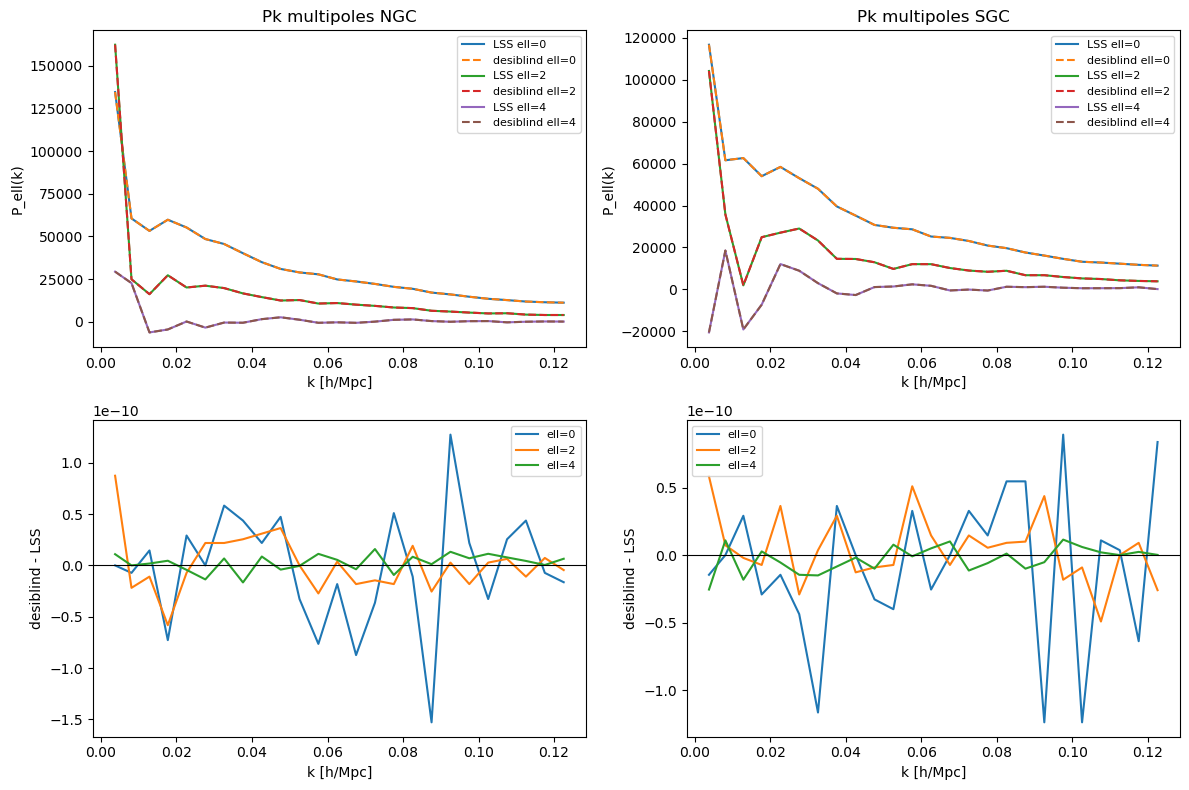

In [9]:
import lsstypes as types

def stat_pair(summary, region, stat_prefix):
    root = Path(summary['output_dir']) / 'stats' / region
    lss = sorted((root / 'lss').glob(f'{stat_prefix}*_{region}_*_lss.h5'))
    desiblind = sorted((root / 'desiblind').glob(f'{stat_prefix}*_{region}_*_desiblind.h5'))
    assert len(lss) == 1 and len(desiblind) == 1, (root, lss, desiblind)
    return lss[0], desiblind[0]

def read_pk_poles(path, ells=(0, 2, 4)):
    spectrum = types.read(path)
    poles = {}
    for ell in ells:
        pole = spectrum.get(ell)
        poles[ell] = (np.asarray(pole.coords()['k']), np.asarray(pole.value()))
    return poles

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, region in enumerate(['NGC', 'SGC']):
    lss_fn, desi_fn = stat_pair(summaries['desi_clustering_pk'], region, 'mesh2_spectrum')
    lss_curves, desi_curves = read_pk_poles(lss_fn), read_pk_poles(desi_fn)
    ax, rax = axes[0, col], axes[1, col]
    for ell, (k, value) in sorted(lss_curves.items()):
        dvalue = desi_curves[ell][1]
        ax.plot(k, value, label=f'LSS ell={ell}')
        ax.plot(k, dvalue, '--', label=f'desiblind ell={ell}')
        residual = dvalue - value
        rax.plot(k, residual, label=f'ell={ell}')
        assert np.max(np.abs(residual)) <= 1e-9
    ax.set_title(f'Pk multipoles {region}')
    ax.set_xlabel('k [h/Mpc]')
    ax.set_ylabel('P_ell(k)')
    ax.legend(fontsize=8)
    rax.set_xlabel('k [h/Mpc]')
    rax.set_ylabel('desiblind - LSS')
    rax.axhline(0, color='k', lw=0.8)
    rax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### xi normalized-count residuals

The `particle2_correlation` HDF5 files store the pair-count grids. The heatmaps below
show residuals for the main count groups; all residuals are at floating-point-zero level. The axes below are bin indices; the following final-xi plots use physical `s` and `mu` coordinates.


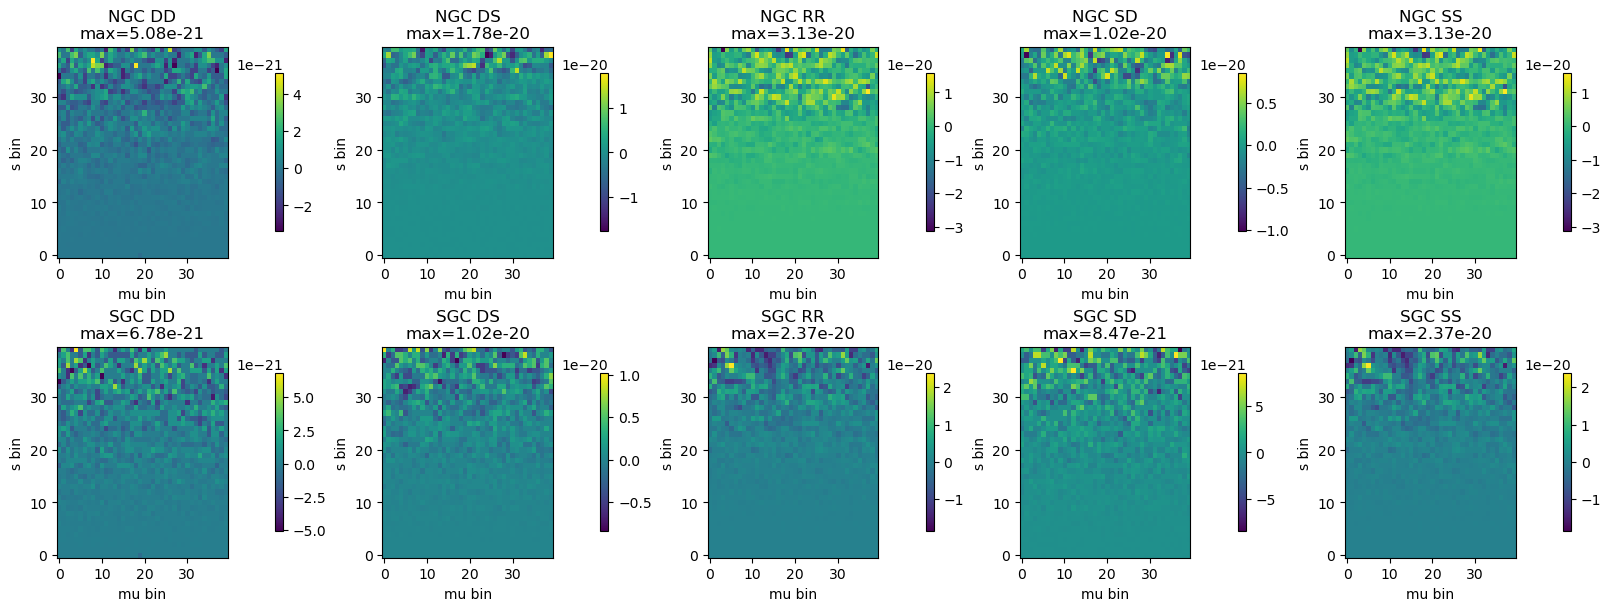

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), constrained_layout=True)
groups = ['DD', 'DS', 'RR', 'SD', 'SS']
for row, region in enumerate(['NGC', 'SGC']):
    lss_fn, desi_fn = stat_pair(summaries['desi_clustering_xi'], region, 'particle2_correlation')
    with h5py.File(lss_fn, 'r') as hl, h5py.File(desi_fn, 'r') as hd:
        for col, group in enumerate(groups):
            residual = np.asarray(hd[group]['normalized_counts']) - np.asarray(hl[group]['normalized_counts'])
            ax = axes[row, col]
            im = ax.imshow(residual, aspect='auto', origin='lower')
            ax.set_title(f'{region} {group}\nmax={np.max(np.abs(residual)):.2e}')
            ax.set_xlabel('mu bin')
            ax.set_ylabel('s bin')
            fig.colorbar(im, ax=ax, shrink=0.75)
plt.show()


### Final xi(s, μ) from the correlation object

The previous heatmaps compare the stored pair-count ingredients directly. The final
xi grid is available from the desi-clustering/`lsstypes` correlation object itself:

```python
correlation = lsstypes.read(filename)
xi_smu = correlation.value()
```

The plots below use the wider `smax=200` validation output and show the final xi grid
for the LSS branch, the desiblind branch, and their residual on physical `(μ, s)` axes.


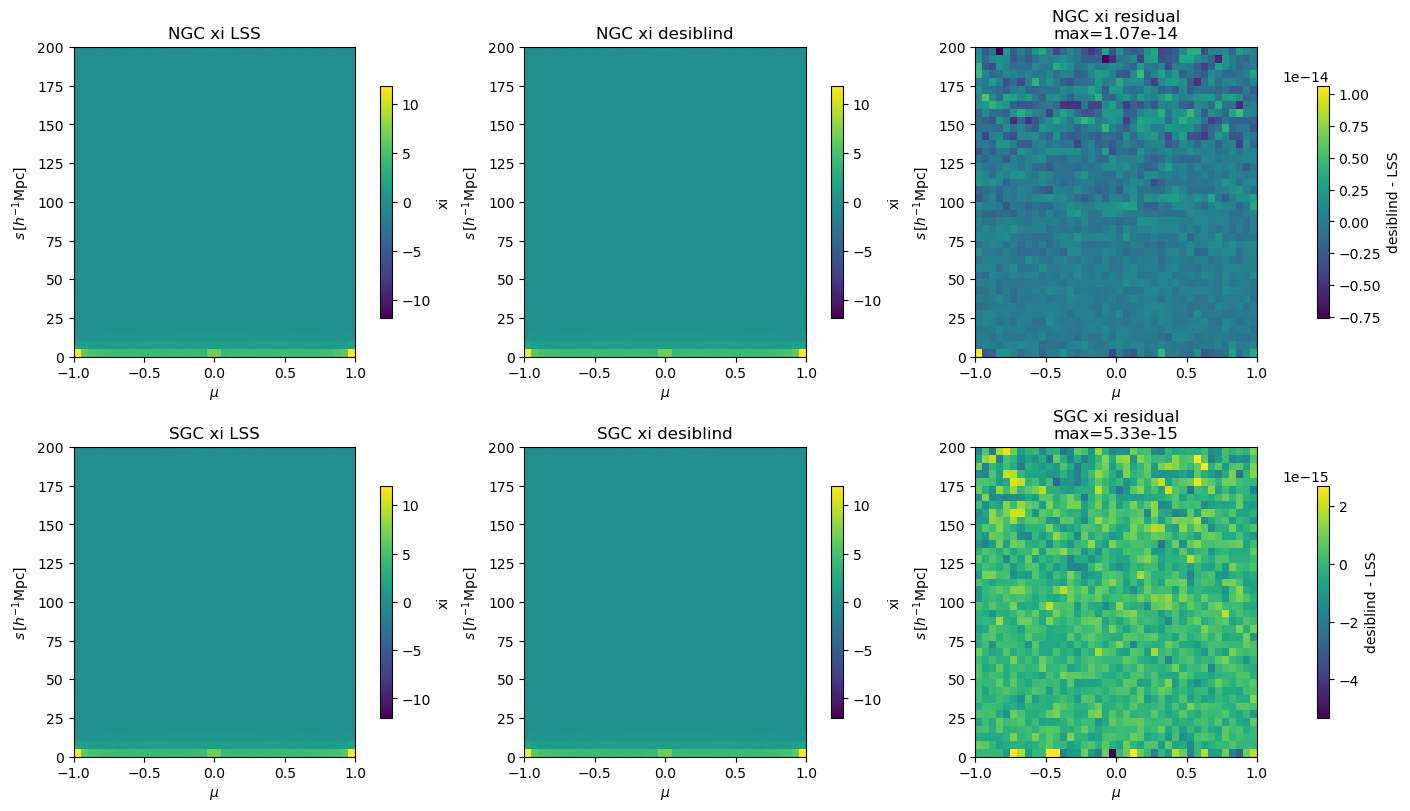

In [11]:
import lsstypes as types

def read_xi_object(path):
    correlation = types.read(path)
    return correlation, np.asarray(correlation.value()), correlation.coords(), correlation.edges()

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for row, region in enumerate(['NGC', 'SGC']):
    lss_fn, desi_fn = stat_pair(summaries['desi_clustering_xi'], region, 'particle2_correlation')
    lss_corr, xi_lss, coords, edges = read_xi_object(lss_fn)
    desi_corr, xi_desi, _, _ = read_xi_object(desi_fn)
    residual = xi_desi - xi_lss
    mu_edges = np.asarray(edges['mu'])
    s_edges = np.asarray(edges['s'])
    mu_plot_edges = np.r_[mu_edges[:, 0], mu_edges[-1, 1]]
    s_plot_edges = np.r_[s_edges[:, 0], s_edges[-1, 1]]
    vmax = max(np.max(np.abs(xi_lss)), np.max(np.abs(xi_desi)))
    panels = [
        (xi_lss, f'{region} xi LSS', (-vmax, vmax), 'xi'),
        (xi_desi, f'{region} xi desiblind', (-vmax, vmax), 'xi'),
        (residual, f'{region} xi residual\nmax={np.max(np.abs(residual)):.2e}', None, 'desiblind - LSS'),
    ]
    for col, (array, title, limits, label) in enumerate(panels):
        ax = axes[row, col]
        kwargs = {}
        if limits is not None:
            kwargs.update(vmin=limits[0], vmax=limits[1])
        im = ax.pcolormesh(mu_plot_edges, s_plot_edges, array, shading='auto', **kwargs)
        ax.set_title(title)
        ax.set_xlabel(r'$\mu$')
        ax.set_ylabel(r'$s\,[h^{-1}{\rm Mpc}]$')
        ax.set_ylim(0, 200)
        fig.colorbar(im, ax=ax, shrink=0.75, label=label)
    assert np.max(np.abs(residual)) <= 1e-10
plt.show()


### xi multipoles from the built-in projection

Use the correlation object's built-in projection method rather than hand-rolling the
Legendre integration:

```python
pole = correlation.project(ell=ell)
```

The plot shows `s² ξ_ℓ(s)` for `ell = 0, 2, 4`, which is the more useful visual scale
for the BAO-region check.


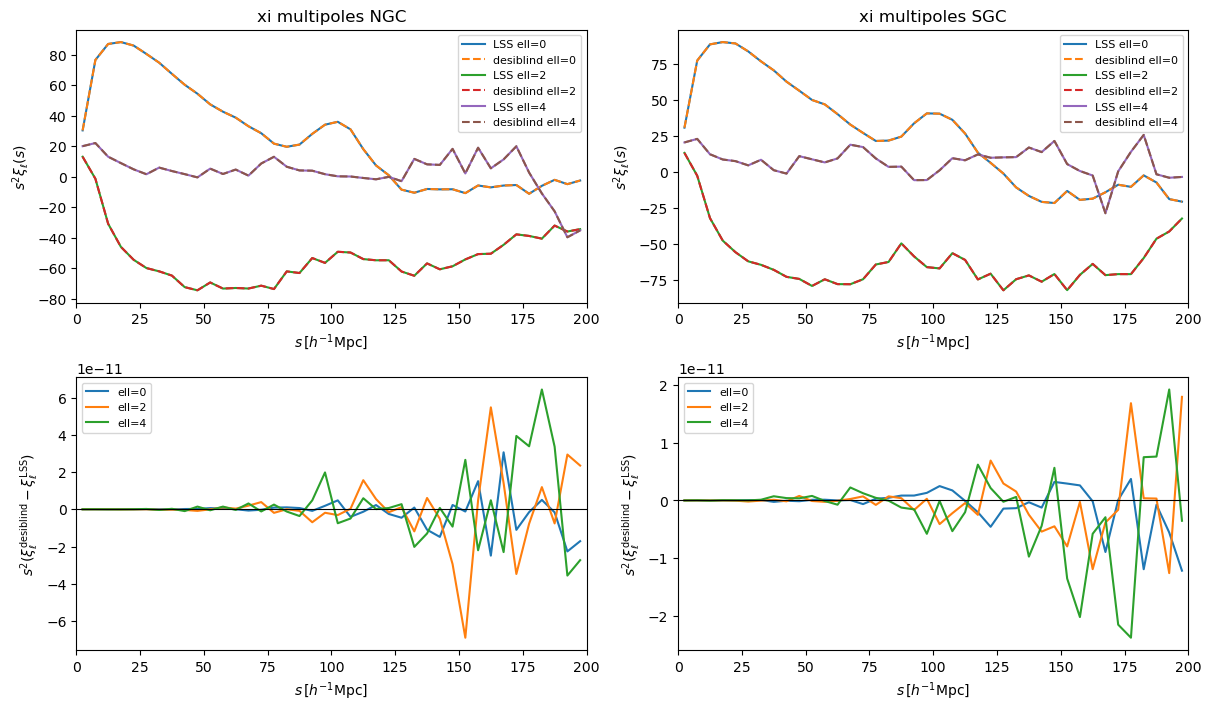

In [12]:
def xi_builtin_multipoles(correlation, ells=(0, 2, 4)):
    poles = {}
    s = None
    for ell in ells:
        pole = correlation.project(ell=ell)
        pole_s = np.asarray(pole.coords()['s'])
        pole_value = np.asarray(pole.value())
        if s is None:
            s = pole_s
        else:
            assert np.allclose(s, pole_s)
        poles[ell] = pole_value
    return s, poles

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for col, region in enumerate(['NGC', 'SGC']):
    lss_fn, desi_fn = stat_pair(summaries['desi_clustering_xi'], region, 'particle2_correlation')
    lss_corr = types.read(lss_fn)
    desi_corr = types.read(desi_fn)
    s, lss_poles = xi_builtin_multipoles(lss_corr)
    _, desi_poles = xi_builtin_multipoles(desi_corr)
    ax = axes[0, col]
    rax = axes[1, col]
    for ell in [0, 2, 4]:
        scale = s**2
        ax.plot(s, scale * lss_poles[ell], label=f'LSS ell={ell}')
        ax.plot(s, scale * desi_poles[ell], linestyle='--', label=f'desiblind ell={ell}')
        residual = desi_poles[ell] - lss_poles[ell]
        rax.plot(s, scale * residual, label=f'ell={ell}')
        assert np.max(np.abs(residual)) <= 1e-10
    ax.set_title(f'xi multipoles {region}')
    ax.set_xlabel(r'$s\,[h^{-1}{\rm Mpc}]$')
    ax.set_ylabel(r'$s^2\xi_\ell(s)$')
    ax.set_xlim(0, 200)
    ax.legend(fontsize=8)
    rax.set_xlabel(r'$s\,[h^{-1}{\rm Mpc}]$')
    rax.set_ylabel(r'$s^2(\xi_\ell^{\rm desiblind} - \xi_\ell^{\rm LSS})$')
    rax.set_xlim(0, 200)
    rax.axhline(0, color='k', lw=0.8)
    rax.legend(fontsize=8)
plt.show()


## 9. Native `desi-clustering` integration smoke tests

These tests exercise the user-facing workflow:

```text
run blinded xi/Pk -> optionally save blinded catalogs -> rerun from saved catalogs
```

The tests are fast smokes, not production-resolution measurements. The pass criterion is
that the statistic produced immediately after in-memory blinding matches the statistic
from the saved blinded catalogs.


In [13]:
native_specs = [
    ('native Pk smoke', 'native_pk_smoke', 1e-12),
    ('native xi smoke', 'native_xi_smoke', 1e-10),
]
native_rows = []
for label, key, tol in native_specs:
    summary = summaries[key]
    delta = float(summary['max_abs_delta'])
    native_rows.append({
        'test': label,
        'summary': str(SUMMARY_PATHS[key]),
        'in_memory_h5': summary['lhs'],
        'from_saved_h5': summary['rhs'],
        'n_saved_catalog_files': len(summary['saved_catalog_files']),
        'max_abs_delta': delta,
        'tolerance': tol,
        'status': status_mark(delta <= tol),
    })
native_df = pd.DataFrame(native_rows)
display(native_df)
assert (native_df['status'] == 'PASS').all(), native_df


,test,summary,in_memory_h5,from_saved_h5,n_saved_catalog_files,max_abs_delta,tolerance,status
0,native Pk smoke,/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/native_smoke_summary.json,/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/stats_in_memory/data-dr2-v2-bao-blinded/mesh2_spectrum_poles_LRG_z0.4-1.1_NGC_weight-default-...,/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/stats_from_saved/mesh2_spectrum_poles_LRG_z0.4-1.1_NGC_weight-default-FKP_saved_blinded.h5,4,0.000000e+00,1.000000e-12,PASS
1,native xi smoke,/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/native_xi_smoke_summary.json,/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/stats_in_memory/data-dr2-v2-bao-blinded/particle2_correlation_smu_LRG_z0.4-1.1_NGC_weight-...,/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/stats_from_saved/particle2_correlation_smu_LRG_z0.4-1.1_NGC_weight-default-FKP_saved_blind...,4,1.482308e-21,1.000000e-10,PASS


### Native smoke saved products

The save side effect writes both NGC and SGC by default even when measuring one cap.
That makes the saved `cat_dir` reusable as normal `desi-clustering` input.


In [14]:
for key in ['native_pk_smoke', 'native_xi_smoke']:
    summary = summaries[key]
    display(Markdown(f'**{key}**'))
    display(pd.DataFrame({'saved_catalog_file': summary['saved_catalog_files']}))
    display(pd.DataFrame({'blinding_record': summary['blinding_records']}))
    for filename in summary['saved_catalog_files'] + summary['blinding_records']:
        assert Path(filename).exists(), filename


**native_pk_smoke**

,saved_catalog_file
0,/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/LSScats/LRG_NGC_0_clustering.ran.fits
1,/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/LSScats/LRG_NGC_clustering.dat.fits
2,/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/LSScats/LRG_SGC_0_clustering.ran.fits
3,/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/LSScats/LRG_SGC_clustering.dat.fits


,blinding_record
0,/pscratch/sd/u/uendert/desiblind_native_smoke/20260624T035237Z/blinding_record_LRG_NGC-SGC.yaml


**native_xi_smoke**

,saved_catalog_file
0,/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/LSScats/LRG_NGC_0_clustering.ran.fits
1,/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/LSScats/LRG_NGC_clustering.dat.fits
2,/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/LSScats/LRG_SGC_0_clustering.ran.fits
3,/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/LSScats/LRG_SGC_clustering.dat.fits


,blinding_record
0,/pscratch/sd/u/uendert/desiblind_native_xi_smoke/20260625T101712Z/blinding_record_LRG_NGC-SGC.yaml


## Final conclusion

All checks in this notebook pass:

- `CatalogBAOBlinder` reproduces the LSS BAO/AP saved-catalog path for the validated
  DA2 LRG workflow.
- The LSS-produced and desiblind-produced blinded catalogs produce indistinguishable
  Pk/xi when measured through `desi-clustering`.
- The native `desi-clustering` integration can run blinded Pk/xi with
  `desiblind.CatalogBAOBlinder`, optionally save blinded LSScats catalogs, and reproduce
  the in-memory blinded measurements when rerun from those saved catalogs.


In [15]:
print('catalog_bao_validation=PASS')


catalog_bao_validation=PASS
